In [12]:
# @title Imports
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.integrate import solve_ivp

import torch
import torch.nn.functional as F
from torch import nn, Tensor
import torch.optim as optim
from torch.autograd.functional import jvp

# @title Device
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print("device =",device)

device = cuda


# Flow Matching

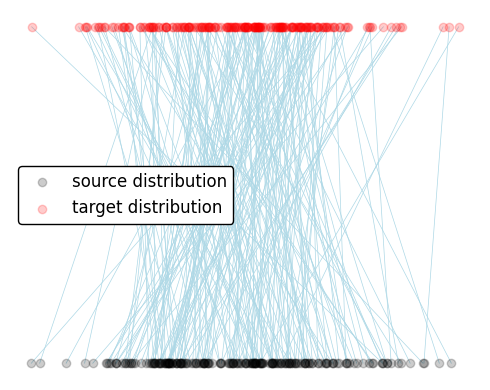

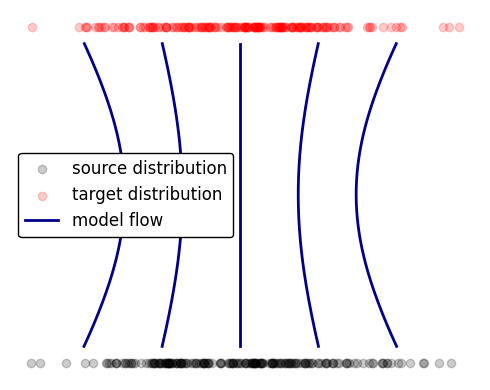

In [3]:
# @title Figure

# Parameters
n_points = 200
mean1, std1 = 0, 1
mean2, std2 = 0, 1

# Generate Gaussian-distributed x values
x1 = np.random.normal(mean1, std1, n_points)
x2 = np.random.normal(mean2, std2, n_points)

# Fixed y positions
y1 = np.zeros_like(x1)
y2 = np.ones_like(x2)

### --- Plot 1: With light blue connecting lines --- ###
plt.figure(figsize=(5, 4))

# Light blue lines connecting x1 to x2
for xi1, xi2 in zip(x1, x2):
    plt.plot([xi1, xi2], [0, 1], color='lightblue', linewidth=0.5, zorder=1)

# Bottom distribution
plt.scatter(x1, y1, color='black', alpha=0.2, label='source distribution', zorder=2)

# Top distribution
plt.scatter(x2, y2, color='red', alpha=0.2, label='target distribution', zorder=2)

# Clean plot
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Legend on center right with opaque box
plt.legend(fontsize=12, loc='center left', framealpha=1, edgecolor='black')

plt.tight_layout()

# Save plot 1
plt.savefig("model_training.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

### --- Plot 2: With model flow curves --- ###

# Analytic solution that minimizes loss for a pair of Gaussians
def v(t, x):
    denom = 1 - 2*t + 2*t**2
    return (2*t - 1) * x / denom

# Time domain
t_vals = np.linspace(0.05, 0.95, 200)

# Select a few x0 values to trace
x0_values = [-2.0, -1.0, 0.0, 1.0, 2.0]

plt.figure(figsize=(5, 4))

# Scatter distributions again
plt.scatter(x1, y1, color='black', alpha=0.2, label='source distribution')
plt.scatter(x2, y2, color='red', alpha=0.2, label='target distribution')

# Integrate model flow for each x0
for i, x0 in enumerate(x0_values):
    sol = solve_ivp(v, [0.05, 0.95], [x0], t_eval=t_vals)
    if i == 0:
        plt.plot(sol.y[0], sol.t, color='darkblue', linewidth=2, label='model flow')
    else:
        plt.plot(sol.y[0], sol.t, color='darkblue', linewidth=2)

# Clean plot
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Legend on center right with opaque box
plt.legend(fontsize=12, loc='center left', framealpha=1, edgecolor='black')

plt.tight_layout()

# Save plot 2
plt.savefig("model_flow.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

# Mean Flow

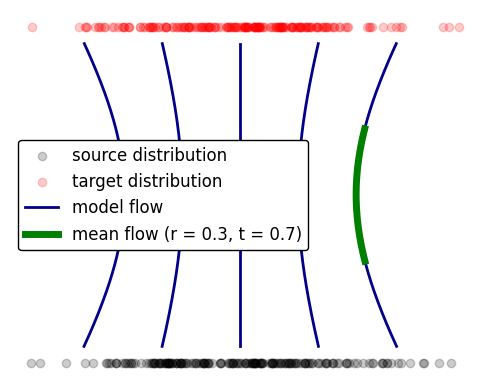

In [4]:
# @title Mean Flow Figure
plt.figure(figsize=(5, 4))

# Scatter distributions
plt.scatter(x1, y1, color='black', alpha=0.2, label='source distribution')
plt.scatter(x2, y2, color='red', alpha=0.2, label='target distribution')

# Integrate model flow for each x0
for i, x0 in enumerate(x0_values):
    sol = solve_ivp(v, [0.05, 0.95], [x0], t_eval=t_vals)
    plt.plot(sol.y[0], sol.t, color='darkblue', linewidth=2,
             label='model flow' if i == 0 else None)

    # Add green segment for the first trajectory only
    if i == 4:
        # Mask a segment
        mask = (sol.t >= 0.3) & (sol.t <= 0.7)
        plt.plot(sol.y[0][mask], sol.t[mask], color='green', linewidth=5, label='mean flow (r = 0.3, t = 0.7)')

# Clean plot
plt.xticks([])
plt.yticks([])
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_visible(False)
plt.gca().spines['bottom'].set_visible(False)

# Legend
plt.legend(fontsize=12, loc='center left', framealpha=1, edgecolor='black')

plt.tight_layout()
plt.savefig("model_flow_highlighted.png", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

## Mean Flow code

In [27]:
# @title Mean Flow Related Code

# Mean Flow Model
class MeanFlowNet(nn.Module):
    def __init__(self, input_dim, h_dim=64):
        super().__init__()
        # Input dimension should be x (input_dim) + t (1) + r (1) = input_dim + 2
        self.fc_in  = nn.Linear(input_dim + 2, h_dim)
        self.fc2    = nn.Linear(h_dim, h_dim)
        self.fc3    = nn.Linear(h_dim, h_dim)
        self.fc4    = nn.Linear(h_dim, h_dim)
        self.fc_out = nn.Linear(h_dim, input_dim)

    def forward(self, x, t, r, act=F.gelu):
        t = t.expand(x.size(0), 1)  # Ensure t has the correct dimensions for x batches
        r = r.expand(x.size(0), 1)  # Add r for meanflow!

        x = torch.cat([x, t, r], dim=1)
        x = act(self.fc_in(x))
        x = act(self.fc2(x))
        x = act(self.fc3(x))
        x = act(self.fc4(x))
        return self.fc_out(x)

# MeanFlow class that handles time generation, loss computation
class MeanFlow:
    def __init__(self,):
        super().__init__()

    def sample_t_r(self, batch_size, device):
        # Generate random t values in the shape of the batch size
        samples = torch.rand(batch_size, 2, device=device)

        # Assign the smaller values to r, larger values to t, unsqueeze to make it fit the 2D data
        t = torch.max(samples[:, 0], samples[:, 1]).unsqueeze(1)
        r = torch.min(samples[:, 0], samples[:, 1]).unsqueeze(1)
        return t, r

    def loss(self, model, target_samples, source_samples):
        batch_size = target_samples.shape[0]
        device = target_samples.device

        t, r = self.sample_t_r(batch_size, device) # Generate t, r

        interpolated_samples = (1 - t) * target_samples + t * source_samples
        velocity = source_samples - target_samples # velocity takes targets to sources

        ## Mean Flow Specific Loss Calculation ##
        jvp_args = (model,(interpolated_samples, t, r),(velocity, torch.ones_like(t), torch.zeros_like(r)), )
        u, dudt = jvp(*jvp_args, create_graph=True)
        u_tgt = velocity - (t - r) * dudt

        ## NOTE: Very important to use .detach().
        ## This sort of gradient based loss is very unstable otherwise
        ## and models can get stuck in extremely terrible local minima!!
        loss = F.mse_loss(u, u_tgt.detach()) ## Default MSE Loss
        return loss

# Training function that uses the class
def train_mean_model(model, source_data_function, target_data_function, n_epochs=100, lr=0.003, batch_size=2048, batches_per_epoch=10, epoch_save_freq = 10, checkpoint_prefix='mean_flow_model'):
    optimizer = optim.Adam(model.parameters(), lr=lr)#torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.0) #different optimizer
    device = next(model.parameters()).device
    #define an instance of meanflow to use to handle times and loss calculation

    meanflow = MeanFlow()

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for batch_idx in range(batches_per_epoch):
            # obtain points
            source_samples = source_data_function(batch_size).to(device)
            target_samples = target_data_function(batch_size).to(device)

            # Use points in the meanflow class
            loss = meanflow.loss(model, target_samples, source_samples)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            total_loss += loss.item()
        avg_loss = total_loss / batches_per_epoch
        print(f"Epoch [{epoch}/{n_epochs}], Avg Loss: {avg_loss:.4f}")

        if epoch % epoch_save_freq == 0:
            # Save model checkpoint
            checkpoint_path = f'{checkpoint_prefix}_epoch_{epoch}.pt'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss.item(),
            }, checkpoint_path)
            print(f"Saved model checkpoint to {checkpoint_path}")
    # Always save final model at the end
    checkpoint_path = f'{checkpoint_prefix}_epoch_{n_epochs}.pt'
    torch.save({
        'epoch': n_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss.item(),
    }, checkpoint_path)
    print(f"Saved model checkpoint to {checkpoint_path}")
    return model

# Example 2D

In [5]:
# @title Distributions
class GaussianGenerator:
    def __init__(self, n_dims=2, noise_std=1.0):
        self.n_dims = n_dims
        self.noise_std = noise_std

    def generate(self, num_points):
        return torch.randn(num_points, self.n_dims) * self.noise_std

class CrescentGenerator:
    def __init__(self, R=1.0, r=0.6, d=0.5):
        self.R = R  # Outer radius
        self.r = r  # Inner circle radius
        self.d = d  # Offset of inner circle

    def generate(self, num_points):
        # Calculate the area ratio to estimate required samples
        outer_area = np.pi * self.R**2
        inner_area = np.pi * self.r**2
        crescent_area = outer_area - inner_area

        # Estimate required samples with 20% buffer
        n_samples = int(num_points * (outer_area / crescent_area) * 1.2)
        n_samples = max(n_samples, num_points)  # Ensure we generate at least num_points

        # Generate points in the outer circle
        theta = 2 * np.pi * torch.rand(n_samples)
        radius = self.R * torch.sqrt(torch.rand(n_samples))

        x = radius * torch.cos(theta)
        y = radius * torch.sin(theta)

        # Filter points that are outside the inner circle
        mask = (x - self.d)**2 + y**2 > self.r**2
        points = torch.stack((x[mask], y[mask]), dim=1)

        # If we didn't get enough points, recursively generate more
        while points.shape[0] < num_points:
            additional_points = self.generate(num_points - points.shape[0])
            points = torch.cat((points, additional_points), dim=0)

        return points[:num_points].to(dtype=torch.float32)

class SpiralGenerator:
    def __init__(self, noise_std=0.1, n_turns=4, radius_scale=0.5):
        self.noise_std = noise_std
        self.n_turns = n_turns
        self.radius_scale = radius_scale

    def generate(self, num_points):
        max_angle = 2 * np.pi * self.n_turns
        t = torch.linspace(0, max_angle, num_points)
        t = t * torch.pow(torch.rand(num_points), 0.5)

        r = self.radius_scale * (t / max_angle + 0.1)
        x = r * torch.cos(t)
        y = r * torch.sin(t)

        x += torch.randn(num_points) * self.noise_std
        y += torch.randn(num_points) * self.noise_std
        return torch.stack([x, y], dim=1)

class CheckerboardGenerator:
    def __init__(self, grid_size=3, scale=5.0, device='cpu'):
        self.grid_size = grid_size
        self.scale = scale
        self.device = device

    def generate(self, num_points):
        grid_length = 2 * self.scale / self.grid_size
        samples = torch.zeros(0, 2).to(self.device)

        while samples.shape[0] < num_points:
            new_samples = (torch.rand(num_points, 2).to(self.device) - 0.5) * 2 * self.scale
            x_mask = torch.floor((new_samples[:, 0] + self.scale) / grid_length) % 2 == 0
            y_mask = torch.floor((new_samples[:, 1] + self.scale) / grid_length) % 2 == 0
            accept_mask = torch.logical_xor(~x_mask, y_mask)
            samples = torch.cat([samples, new_samples[accept_mask]], dim=0)

        return samples[:num_points]

## Display example

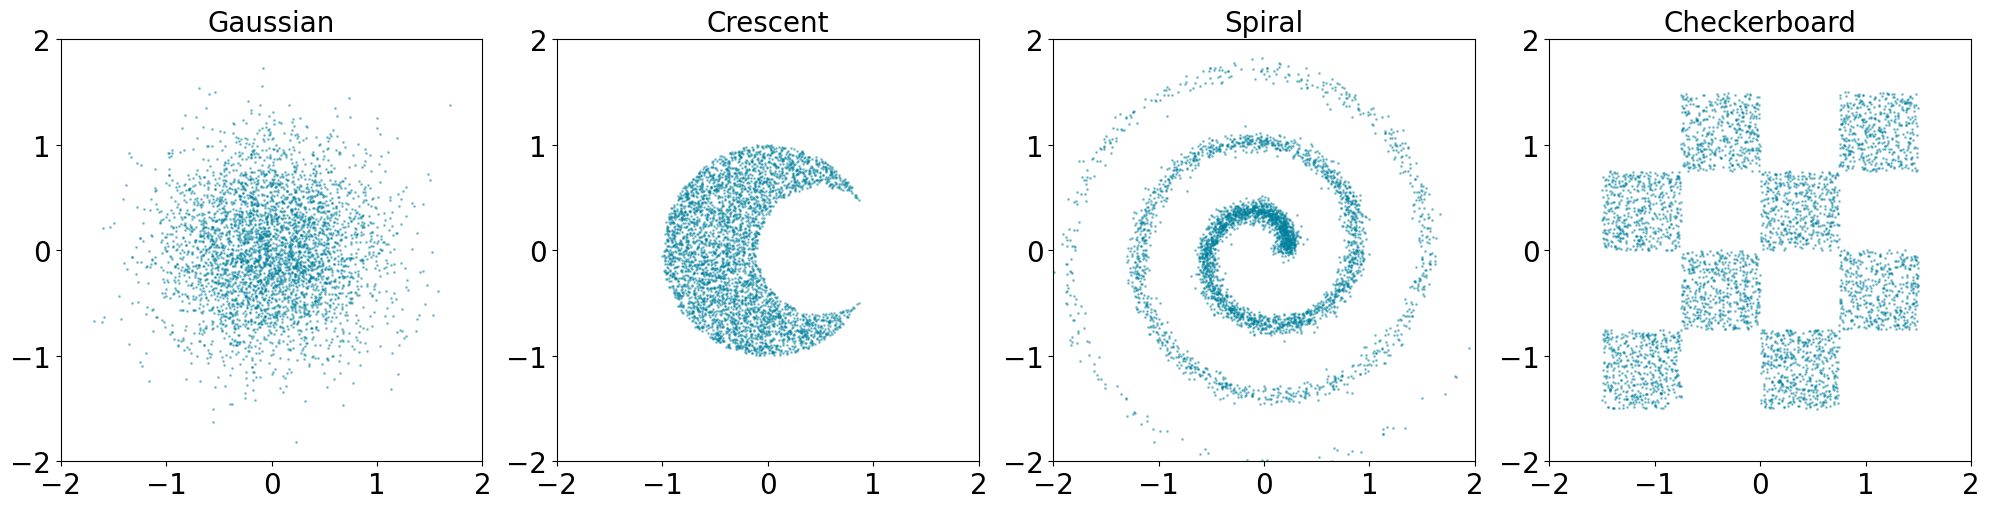

In [6]:
# @title Example Display
# Initialize generators with different parameters
generators = [
    GaussianGenerator(n_dims=2, noise_std=0.5),
    CrescentGenerator(R=1.0, r=0.6, d=0.5),
    SpiralGenerator(noise_std=0.05, n_turns=3, radius_scale=2),
    CheckerboardGenerator(grid_size=4, scale=1.5)
]
# Generate samples from each distribution
num_points = 4000
samples = [generator.generate(num_points) for generator in generators]
titles = ["Gaussian", "Crescent", "Spiral", "Checkerboard"]

# Plot the distributions
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, sample, title in zip(axes, samples, titles):
    ax.scatter(sample[:, 0], sample[:, 1], s=1, alpha=0.4, color='#00809D')
    ax.set_title(title, fontsize = 20)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.tick_params(axis='both', which='major', labelsize=20)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Save example 

In [7]:
for sample, title in zip(samples, titles):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(sample[:, 0], sample[:, 1], s=1, alpha=0.5, color='#00809D')
    # ax.set_title(title, fontsize=20)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.set_aspect('equal')
    plt.tight_layout()
    
    # Save each figure separately
    filename = f"{title.lower()}_distribution.pdf"
    plt.savefig(filename, format='pdf', bbox_inches='tight')
    plt.close(fig)  # Close the figure to free memory

# Visualization function 

In [67]:
# @title Visualization Functions
def visualize_denoising_progress(
    n_epochs,
    initial_points,
    num_steps_multi,
    model_class,
    model_kwargs,
    target_points,
    integration_fn,
    checkpoint_prefix='mean_flow_model',
    epoch_step=10,
    device='cpu',
    suptitle="Model Performance Over Time"
):
    """
    Visualizes denoising results across training epochs using two schemes:
    multi-step and single-step denoising.

    Args:
        n_epochs: Total number of training epochs.
        initial_points: Noisy input points (torch.Tensor).
        num_steps_multi: Integration steps for multi-step denoising.
        model_class: Class of the flow model (e.g., MeanFlowNet).
        model_kwargs: Dict of kwargs to initialize model (e.g., {'input_dim': 2, 'h_dim': 128}).
        target_points: Target distribution (numpy array).
        integration_fn: Function that performs forward integration.
        checkpoint_prefix: Prefix of checkpoint files.
        epoch_step: Interval at which to visualize checkpoints.
        device: Torch device.
        suptitle: Title for the entire figure.
    """
    steps = list(range(0, n_epochs + 1, epoch_step))
    n_rows = len(steps)
    fig, axes = plt.subplots(n_rows, 2, figsize=(8, 4 * n_rows))

    for i, epoch in enumerate(steps):
        model_name = f'{checkpoint_prefix}_epoch_{epoch}.pt'
        print(f"Loading model {model_name}")

        # Instantiate and load model
        plot_model = model_class(**model_kwargs).to(device)
        checkpoint = torch.load(model_name, map_location=device)
        plot_model.load_state_dict(checkpoint['model_state_dict'])
        plot_model.eval()

        # Multi-step denoising
        denoised_multi = integration_fn(
            initial_points,
            model=plot_model,
            t_start=1.0, #we start at t = 1, corresponding to noise
            t_end=0.0, #and end at t = 0, corresponding to data
            num_steps=num_steps_multi,
            save_trajectory=False,
            device = device
        ).cpu().numpy()

        # Single-step denoising
        denoised_single = integration_fn(
            initial_points,
            model=plot_model,
            t_start=1.0,
            t_end=0.0,
            num_steps=1,
            save_trajectory=False,
            device = device
        ).cpu().numpy()

        # Left: multi-step
        ax_left = axes[i, 0]
        ax_left.scatter(target_points[:, 0], target_points[:, 1], s=5, alpha=0.2, color='#00809D', label='Target')
        ax_left.scatter(denoised_multi[:, 0], denoised_multi[:, 1], s=5, alpha=0.3, color='#FF7A30', label='Denoised')
        ax_left.set_xlim(-2, 2)
        ax_left.set_ylim(-2, 2)
        ax_left.set_aspect('equal')
        if i == 0:
            ax_left.set_title(f'Denoising Steps = {num_steps_multi}', fontsize=20)
        ax_left.set_ylabel(f"Epoch {epoch}", fontsize=16)
        ax_left.grid(True, alpha=0.3)

        # Right: single-step
        ax_right = axes[i, 1]
        ax_right.scatter(target_points[:, 0], target_points[:, 1], s=5, alpha=0.2, color='#00809D', label='Target')
        ax_right.scatter(denoised_single[:, 0], denoised_single[:, 1], s=5, alpha=0.3, color='#FF7A30', label='Denoised')
        ax_right.set_xlim(-2, 2)
        ax_right.set_ylim(-2, 2)
        ax_right.set_aspect('equal')
        if i == 0:
            ax_right.set_title('Denoising Steps = 1', fontsize=20)
        ax_right.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.suptitle(suptitle, fontsize=25, y=1.02)
    plt.show()

# Optional visualization function
# In case you want to see how a particular model
# does at intermediate time steps
def visualize_flow(
    model,
    initial_points,
    target_points,
    t_start=0.0,
    t_end=1.0,
    num_steps=100,
    time_steps_to_plot=[0, 25, 50, 75, 100],
    figsize=(20, 4)
):
    """
    Visualizes the flow results at specified time steps.

    Args:
        model: Trained flow model
        initial_points (torch.Tensor): Starting points
        target_points (np.ndarray): Target distribution
        t_start (float): Start time
        t_end (float): End time
        num_steps (int): Total integration steps
        time_steps_to_plot (list of int): Which steps to visualize
        figsize (tuple): Figure size
    """
    # Compute trajectories
    trajectory = forward_euler_integration_model(
        initial_points, model = model,
        t_start=t_start, t_end=t_end,
        num_steps=num_steps, save_trajectory=True
    )
    trajectory_np = trajectory.cpu().numpy()

    # Plot
    plt.figure(figsize=figsize)
    for i, step in enumerate(time_steps_to_plot):
        plt.subplot(1, len(time_steps_to_plot), i + 1)
        plt.scatter(target_points[:, 0], target_points[:, 1], s=5, alpha=0.1, color='blue', label='Target')
        plt.scatter(trajectory_np[step, :, 0], trajectory_np[step, :, 1], s=5, alpha=0.4, color='red',
                    label=f'Transformed (t={step / num_steps:.2f})')
        plt.xlim(-3, 3)
        plt.ylim(-3, 3)
        plt.gca().set_aspect('equal')
        plt.title(f't = {step / num_steps:.2f}')
        plt.legend()
        plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Distribution Selection

In [9]:
# Initialize distributions
source_generator = GaussianGenerator(n_dims=2, noise_std=1.0)  # Mean=0, Std=1
target_generator = CheckerboardGenerator(grid_size=4, scale=1.5)

# Generate test data
num_points = 4000
initial_points = source_generator.generate(num_points)
target_points = target_generator.generate(num_points)

# Flow Example 

In [10]:
# @title Flow Matching Model + Training Function
class VelocityNet(nn.Module):
    def __init__(self, input_dim, h_dim=64):
        super().__init__()
        self.fc_in  = nn.Linear(input_dim + 1, h_dim)
        self.fc2    = nn.Linear(h_dim, h_dim)
        self.fc3    = nn.Linear(h_dim, h_dim)
        self.fc_out = nn.Linear(h_dim, input_dim)

    def forward(self, x, t, act=F.gelu):
        t = t.expand(x.size(0), 1)  # Ensure t has the correct dimensions
        x = torch.cat([x, t], dim=1)
        x = act(self.fc_in(x))
        x = act(self.fc2(x))
        x = act(self.fc3(x))
        return self.fc_out(x)

def train_model(model, source_data_function, target_data_function, n_epochs=100, lr=0.003, batch_size=2048, batches_per_epoch=10, epoch_save_freq = 10, checkpoint_prefix='flow_model'):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    device = next(model.parameters()).device
    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for batch_idx in range(batches_per_epoch):
            optimizer.zero_grad()

            # obtain points
            source_samples = source_data_function(batch_size).to(device)
            target_samples = target_data_function(batch_size).to(device)

            t = torch.rand(source_samples.size(0), 1).to(device)  # random times for traning
            interpolated_samples = (1 - t) * target_samples + t * source_samples
            velocity = source_samples - target_samples # velocity takes targets to sources

            velocity_prediction = model(interpolated_samples, t)
            loss = loss_fn(velocity_prediction, velocity)

            loss.backward()
            optimizer.step()
        total_loss += loss.item()
        avg_loss = total_loss / batches_per_epoch
        print(f"Epoch [{epoch+1}/{n_epochs}], Avg Loss: {avg_loss:.4f}")

        if epoch % epoch_save_freq == 0:
            # Save model checkpoint
            checkpoint_path = f'{checkpoint_prefix}_epoch_{epoch}.pt'
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': loss.item(),
            }, checkpoint_path)
            print(f"Saved model checkpoint to {checkpoint_path}")
    # Always save final model at the end
    checkpoint_path = f'{checkpoint_prefix}_epoch_{n_epochs}.pt'
    torch.save({
        'epoch': n_epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss.item(),
    }, checkpoint_path)
    print(f"Saved model checkpoint to {checkpoint_path}")
    return model

## Train

In [13]:
model = VelocityNet(input_dim=2, h_dim=128).to(device)
checkpoint_prefix='flow_model'

n_epoch_flow = 60

start_time = time.time()

trained_model = train_model(
    model=model,
    source_data_function=source_generator.generate,
    target_data_function=target_generator.generate,
    n_epochs=n_epoch_flow,
    lr=0.003,
    batch_size=4096,
    batches_per_epoch=50,
    epoch_save_freq=10,
    checkpoint_prefix=checkpoint_prefix
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training took {elapsed_time:.2f} seconds")

Epoch [1/60], Avg Loss: 0.0267
Saved model checkpoint to flow_model_epoch_0.pt
Epoch [2/60], Avg Loss: 0.0260
Epoch [3/60], Avg Loss: 0.0271
Epoch [4/60], Avg Loss: 0.0259
Epoch [5/60], Avg Loss: 0.0262
Epoch [6/60], Avg Loss: 0.0263
Epoch [7/60], Avg Loss: 0.0262
Epoch [8/60], Avg Loss: 0.0256
Epoch [9/60], Avg Loss: 0.0257
Epoch [10/60], Avg Loss: 0.0262
Epoch [11/60], Avg Loss: 0.0253
Saved model checkpoint to flow_model_epoch_10.pt
Epoch [12/60], Avg Loss: 0.0259
Epoch [13/60], Avg Loss: 0.0260
Epoch [14/60], Avg Loss: 0.0257
Epoch [15/60], Avg Loss: 0.0252
Epoch [16/60], Avg Loss: 0.0263
Epoch [17/60], Avg Loss: 0.0258
Epoch [18/60], Avg Loss: 0.0264
Epoch [19/60], Avg Loss: 0.0257
Epoch [20/60], Avg Loss: 0.0261
Epoch [21/60], Avg Loss: 0.0263
Saved model checkpoint to flow_model_epoch_20.pt
Epoch [22/60], Avg Loss: 0.0256
Epoch [23/60], Avg Loss: 0.0255
Epoch [24/60], Avg Loss: 0.0256
Epoch [25/60], Avg Loss: 0.0254
Epoch [26/60], Avg Loss: 0.0257
Epoch [27/60], Avg Loss: 0.0258

## Numerical Integration - Flowmatching 

In [14]:
# @title Numerical Integration - Flow Matching
def forward_euler_integration_model(
    initial_points: torch.Tensor,
    model: nn.Module,
    t_start: float = 1.0,
    t_end: float = 0.0,
    num_steps: int = 100,
    save_trajectory: bool = True,
    device = 'cpu'
) -> torch.Tensor:

    dt = (t_start - t_end) / num_steps
    trajectory = [initial_points.clone()] if save_trajectory else None
    current_points = initial_points.clone().to(device)

    for step in range(0, num_steps):
        current_time = t_start - step*dt
        t_tensor = torch.full((len(current_points), 1), current_time,
                            device=current_points.device)

        with torch.no_grad():
            velocity = model(current_points, t_tensor)

        current_points += -velocity * dt # velocity takes us from targets to source

        if save_trajectory:
            trajectory.append(current_points.clone())

    return torch.stack(trajectory) if save_trajectory else current_points

## Visualize progress

Loading model flow_model_epoch_0.pt
Loading model flow_model_epoch_20.pt
Loading model flow_model_epoch_40.pt
Loading model flow_model_epoch_60.pt


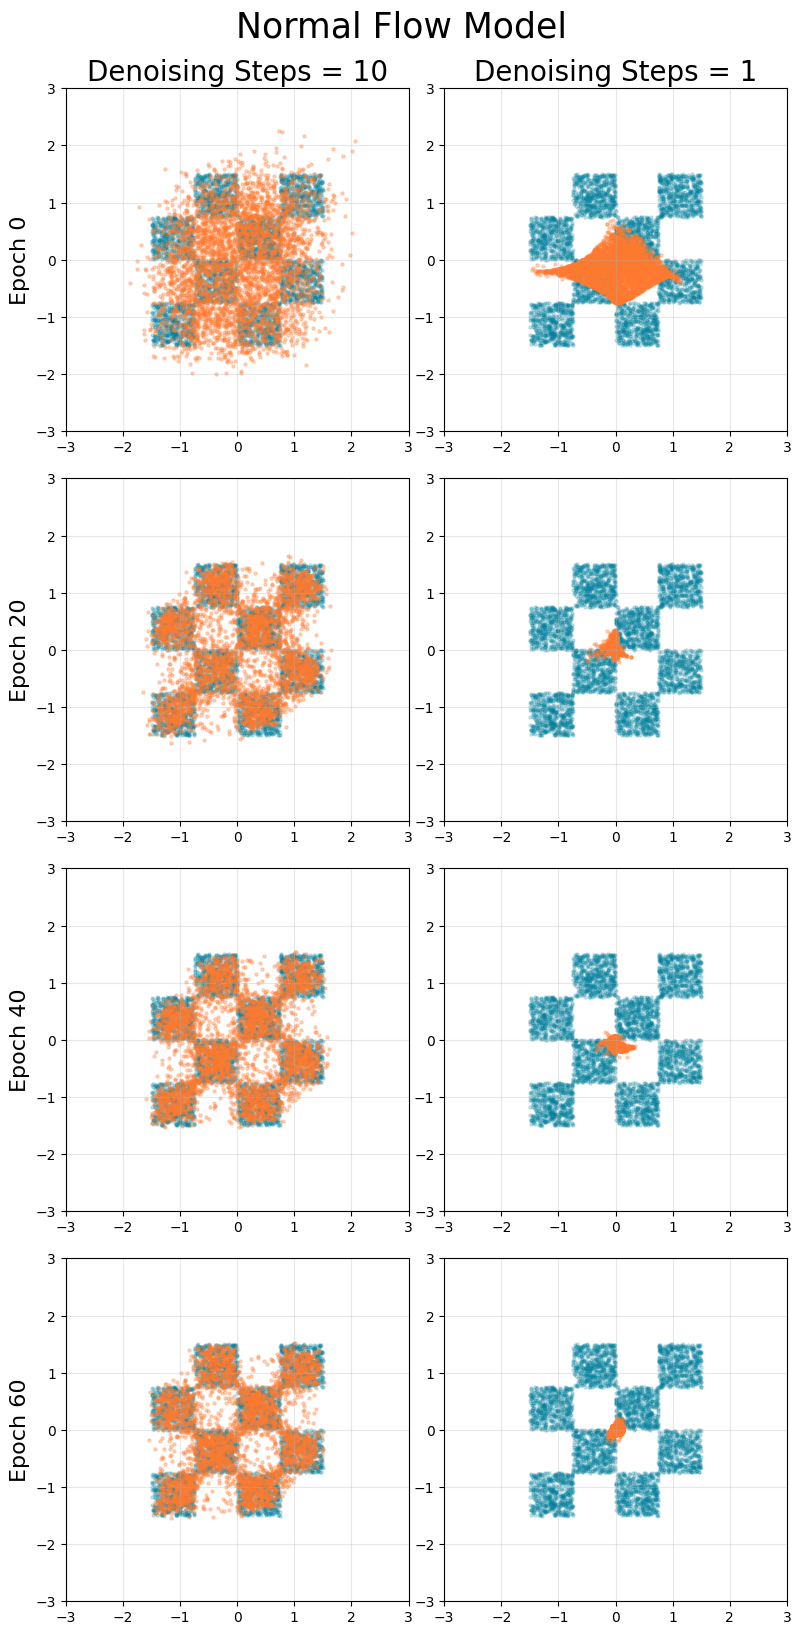

In [25]:
visualize_denoising_progress(
    n_epochs=n_epoch_flow,
    initial_points=initial_points,
    num_steps_multi=10,
    model_class=VelocityNet,
    model_kwargs={'input_dim': 2, 'h_dim': 128},  # model initialization parameters
    target_points=target_points,
    integration_fn = forward_euler_integration_model,
    checkpoint_prefix=checkpoint_prefix,
    suptitle="Normal Flow Model",
    epoch_step=20,
    device=device
)

# DDPM Example 

In [ ]:
# Simple 2D MLP for DDPM
class DenoiseNet(nn.Module):
    def __init__(self, input_dim=2, h_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim + 1, h_dim),
            nn.GELU(),
            nn.Linear(h_dim, h_dim),
            nn.GELU(),
            nn.Linear(h_dim, h_dim),
            nn.GELU(),
            nn.Linear(h_dim, input_dim),
        )

    def forward(self, x, t):
        # Embed t as a feature
        t = t.view(-1, 1)
        xt = torch.cat([x, t], dim=1)
        return self.net(xt)
    


def get_noise_schedule(T, beta_start=1e-4, beta_end=0.02):
    betas = torch.linspace(beta_start, beta_end, T)
    alphas = 1. - betas
    alpha_hats = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_hats

In [ ]:
def train_ddpm(model, data_gen_fn, n_epochs=100, T=1000, batch_size=2048, lr=1e-3, device='cuda'):
    betas, alphas, alpha_hats = get_noise_schedule(T)
    betas, alphas, alpha_hats = betas.to(device), alphas.to(device), alpha_hats.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(n_epochs):
        model.train()
        x_0 = data_gen_fn(batch_size).to(device)  # real data
        t = torch.randint(0, T, (batch_size,), device=device)

        noise = torch.randn_like(x_0)
        alpha_hat_t = alpha_hats[t].view(-1, 1)

        x_t = torch.sqrt(alpha_hat_t) * x_0 + torch.sqrt(1 - alpha_hat_t) * noise
        noise_pred = model(x_t, t.float() / T)

        loss = loss_fn(noise_pred, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d} | Loss: {loss.item():.4f}")

In [ ]:
@torch.no_grad()
def sample_ddpm(model, n_samples, T=1000, device='cuda'):
    betas, alphas, alpha_hats = get_noise_schedule(T)
    betas, alphas, alpha_hats = betas.to(device), alphas.to(device), alpha_hats.to(device)

    x_t = torch.randn(n_samples, 2).to(device)  # Start from noise

    for t in reversed(range(T)):
        t_tensor = torch.full((n_samples,), t, device=device).float() / T
        z = torch.randn_like(x_t) if t > 0 else torch.zeros_like(x_t)
        alpha_t = alphas[t]
        alpha_hat_t = alpha_hats[t]
        beta_t = betas[t]

        eps_theta = model(x_t, t_tensor)

        x_t = (
            1 / torch.sqrt(alpha_t)
            * (x_t - (beta_t / torch.sqrt(1 - alpha_hat_t)) * eps_theta)
            + torch.sqrt(beta_t) * z
        )
    return x_t.cpu()

In [ ]:
ddpm_model = DenoiseNet(input_dim=2, h_dim=128).to(device)

train_ddpm(
    model=ddpm_model,
    data_gen_fn=target_generator.generate,  # Replace with your generator
    n_epochs=100,
    T=1000,
    batch_size=4096,
    lr=1e-3,
    device=device
)

samples = sample_ddpm(ddpm_model, n_samples=4000, T=1000, device=device)

# Visualization
import matplotlib.pyplot as plt
plt.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.2)
plt.title("DDPM Generated Samples")
plt.axis("equal")
plt.show()

# MEAN FLOW EXAMPLE 

In [28]:
mean_model = MeanFlowNet(input_dim=2, h_dim=128).to(device)
mean_checkpoint_prefix='mean_flow_model'

In [29]:
# Train the model
n_epochs = 100

start_time = time.time()

trained_model = train_mean_model(
    model=mean_model,
    source_data_function=source_generator.generate,
    target_data_function=target_generator.generate,
    n_epochs=n_epochs,
    lr=0.003,
    batch_size=4096,
    batches_per_epoch=50,
    epoch_save_freq=10,
    checkpoint_prefix=mean_checkpoint_prefix
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training took {elapsed_time:.2f} seconds")

Epoch [0/100], Avg Loss: 1.1675
Saved model checkpoint to mean_flow_model_epoch_0.pt
Epoch [1/100], Avg Loss: 1.2457
Epoch [2/100], Avg Loss: 1.3131
Epoch [3/100], Avg Loss: 1.3391
Epoch [4/100], Avg Loss: 1.3270
Epoch [5/100], Avg Loss: 1.3467
Epoch [6/100], Avg Loss: 1.3379
Epoch [7/100], Avg Loss: 1.3367
Epoch [8/100], Avg Loss: 1.3596
Epoch [9/100], Avg Loss: 1.3544
Epoch [10/100], Avg Loss: 1.3782
Saved model checkpoint to mean_flow_model_epoch_10.pt
Epoch [11/100], Avg Loss: 1.3605
Epoch [12/100], Avg Loss: 1.3756
Epoch [13/100], Avg Loss: 1.3824
Epoch [14/100], Avg Loss: 1.3881
Epoch [15/100], Avg Loss: 1.3943
Epoch [16/100], Avg Loss: 1.4147
Epoch [17/100], Avg Loss: 1.4304
Epoch [18/100], Avg Loss: 1.4280
Epoch [19/100], Avg Loss: 1.4382
Epoch [20/100], Avg Loss: 1.4476
Saved model checkpoint to mean_flow_model_epoch_20.pt
Epoch [21/100], Avg Loss: 1.4498
Epoch [22/100], Avg Loss: 1.4631
Epoch [23/100], Avg Loss: 1.4619
Epoch [24/100], Avg Loss: 1.4730
Epoch [25/100], Avg Loss

##  Nummerical Integration Mean Flow 

In [30]:
# @title Numerical Integration - Mean Flow
def forward_euler_integration_mean_model(
    initial_points: torch.Tensor,
    model: nn.Module,
    t_start: float = 1.0,
    t_end: float = 0.0,
    num_steps: int = 100,
    save_trajectory: bool = True,
    device = 'cpu'
) -> torch.Tensor:

    dt = (t_start - t_end) / num_steps
    trajectory = [initial_points.clone()] if save_trajectory else None
    current_points = initial_points.clone().to(device)

    for step in range(0, num_steps):
        current_t = t_start - step*dt
        current_r = current_t - dt # Remember, the r values are smaller than t!
        #print ("Current time ", current_r , " moving to ", current_t)
        t_tensor = torch.full((len(current_points), 1), current_t,
                            device=current_points.device)
        r_tensor = torch.full((len(current_points), 1), current_r,
                            device=current_points.device)

        with torch.no_grad():
            velocity = model(current_points, t_tensor, r_tensor)

        current_points += -velocity * dt  # negative because our velocity moves from target to source

        if save_trajectory:
            trajectory.append(current_points.clone())

    return torch.stack(trajectory) if save_trajectory else current_points

## Visualize progress

Loading model mean_flow_model_epoch_0.pt
Loading model mean_flow_model_epoch_20.pt
Loading model mean_flow_model_epoch_40.pt
Loading model mean_flow_model_epoch_60.pt
Loading model mean_flow_model_epoch_80.pt
Loading model mean_flow_model_epoch_100.pt


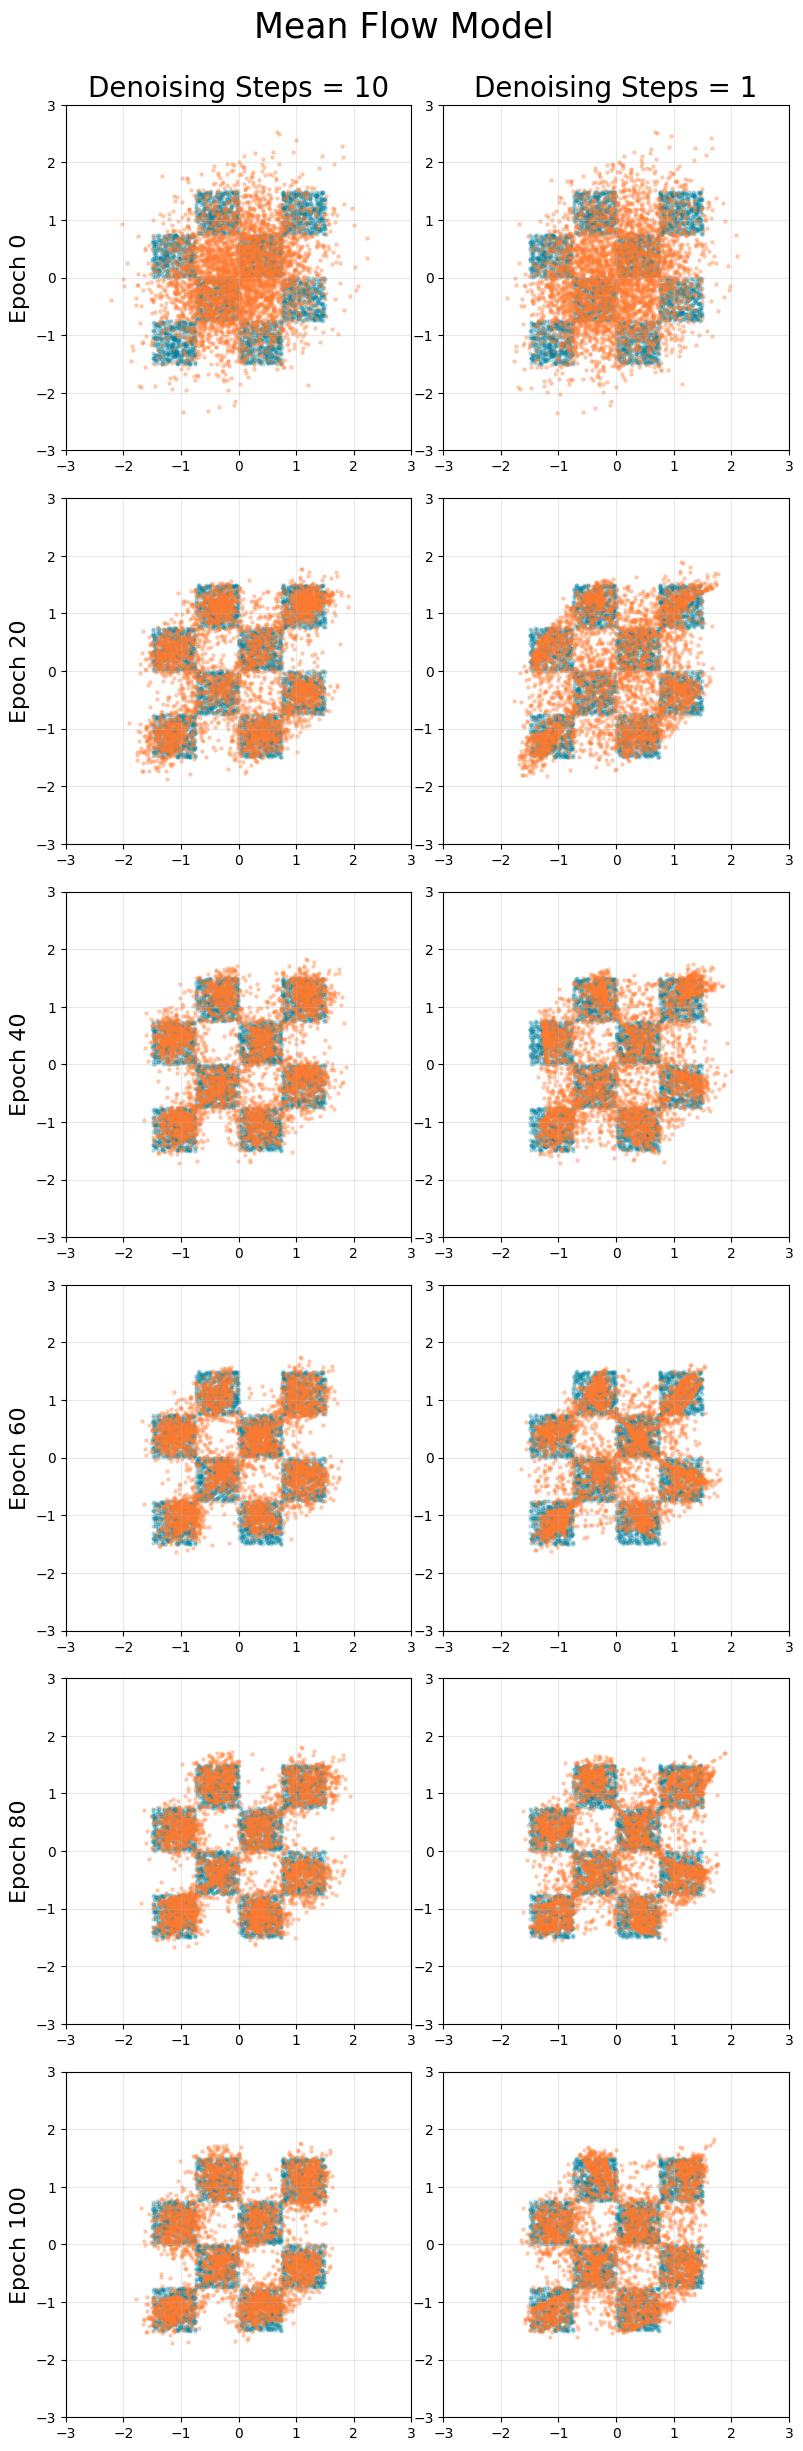

In [31]:
visualize_denoising_progress(
    n_epochs=n_epochs,
    initial_points=initial_points,
    num_steps_multi=10,
    model_class=MeanFlowNet,
    model_kwargs={'input_dim': 2, 'h_dim': 128},  # model initialization parameters
    target_points=target_points,
    integration_fn = forward_euler_integration_mean_model,
    checkpoint_prefix=mean_checkpoint_prefix,
    suptitle="Mean Flow Model",
    epoch_step=20,
    device=device
)

# Crescent Distribution

In [68]:
# @title Initialize Crescent
target_generator_crescent = CrescentGenerator(R=1.0, r=0.6, d=0.5)

# Generate test data
num_points = 4000
initial_points = source_generator.generate(num_points)
target_points = target_generator_crescent.generate(num_points)

## Flow Matching 

### Train code 

In [54]:
# @title Flow Matching Model
model = VelocityNet(input_dim=2, h_dim=128).to(device)
crescent_checkpoint_prefix='crescent_flow_model'

In [59]:
# @title Training
n_epoch_flow = 60

start_time = time.time()

trained_model = train_model(
    model=model,
    source_data_function=source_generator.generate,
    target_data_function=target_generator_crescent.generate,
    n_epochs=n_epoch_flow,
    lr=0.003,
    batch_size=4096,
    batches_per_epoch=50,
    epoch_save_freq=10,
    checkpoint_prefix=crescent_checkpoint_prefix
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training took {elapsed_time:.2f} seconds")

Epoch [1/60], Avg Loss: 0.0146
Saved model checkpoint to crescent_flow_model_epoch_0.pt
Epoch [2/60], Avg Loss: 0.0142
Epoch [3/60], Avg Loss: 0.0148
Epoch [4/60], Avg Loss: 0.0142
Epoch [5/60], Avg Loss: 0.0146
Epoch [6/60], Avg Loss: 0.0144
Epoch [7/60], Avg Loss: 0.0147
Epoch [8/60], Avg Loss: 0.0145
Epoch [9/60], Avg Loss: 0.0147
Epoch [10/60], Avg Loss: 0.0147
Epoch [11/60], Avg Loss: 0.0149
Saved model checkpoint to crescent_flow_model_epoch_10.pt
Epoch [12/60], Avg Loss: 0.0146
Epoch [13/60], Avg Loss: 0.0139
Epoch [14/60], Avg Loss: 0.0147
Epoch [15/60], Avg Loss: 0.0140
Epoch [16/60], Avg Loss: 0.0146
Epoch [17/60], Avg Loss: 0.0148
Epoch [18/60], Avg Loss: 0.0143
Epoch [19/60], Avg Loss: 0.0149
Epoch [20/60], Avg Loss: 0.0142
Epoch [21/60], Avg Loss: 0.0139
Saved model checkpoint to crescent_flow_model_epoch_20.pt
Epoch [22/60], Avg Loss: 0.0145
Epoch [23/60], Avg Loss: 0.0146
Epoch [24/60], Avg Loss: 0.0146
Epoch [25/60], Avg Loss: 0.0149
Epoch [26/60], Avg Loss: 0.0150
Epoc

### Visualization 

Loading model crescent_flow_model_epoch_0.pt
Loading model crescent_flow_model_epoch_10.pt
Loading model crescent_flow_model_epoch_20.pt
Loading model crescent_flow_model_epoch_30.pt
Loading model crescent_flow_model_epoch_40.pt
Loading model crescent_flow_model_epoch_50.pt
Loading model crescent_flow_model_epoch_60.pt


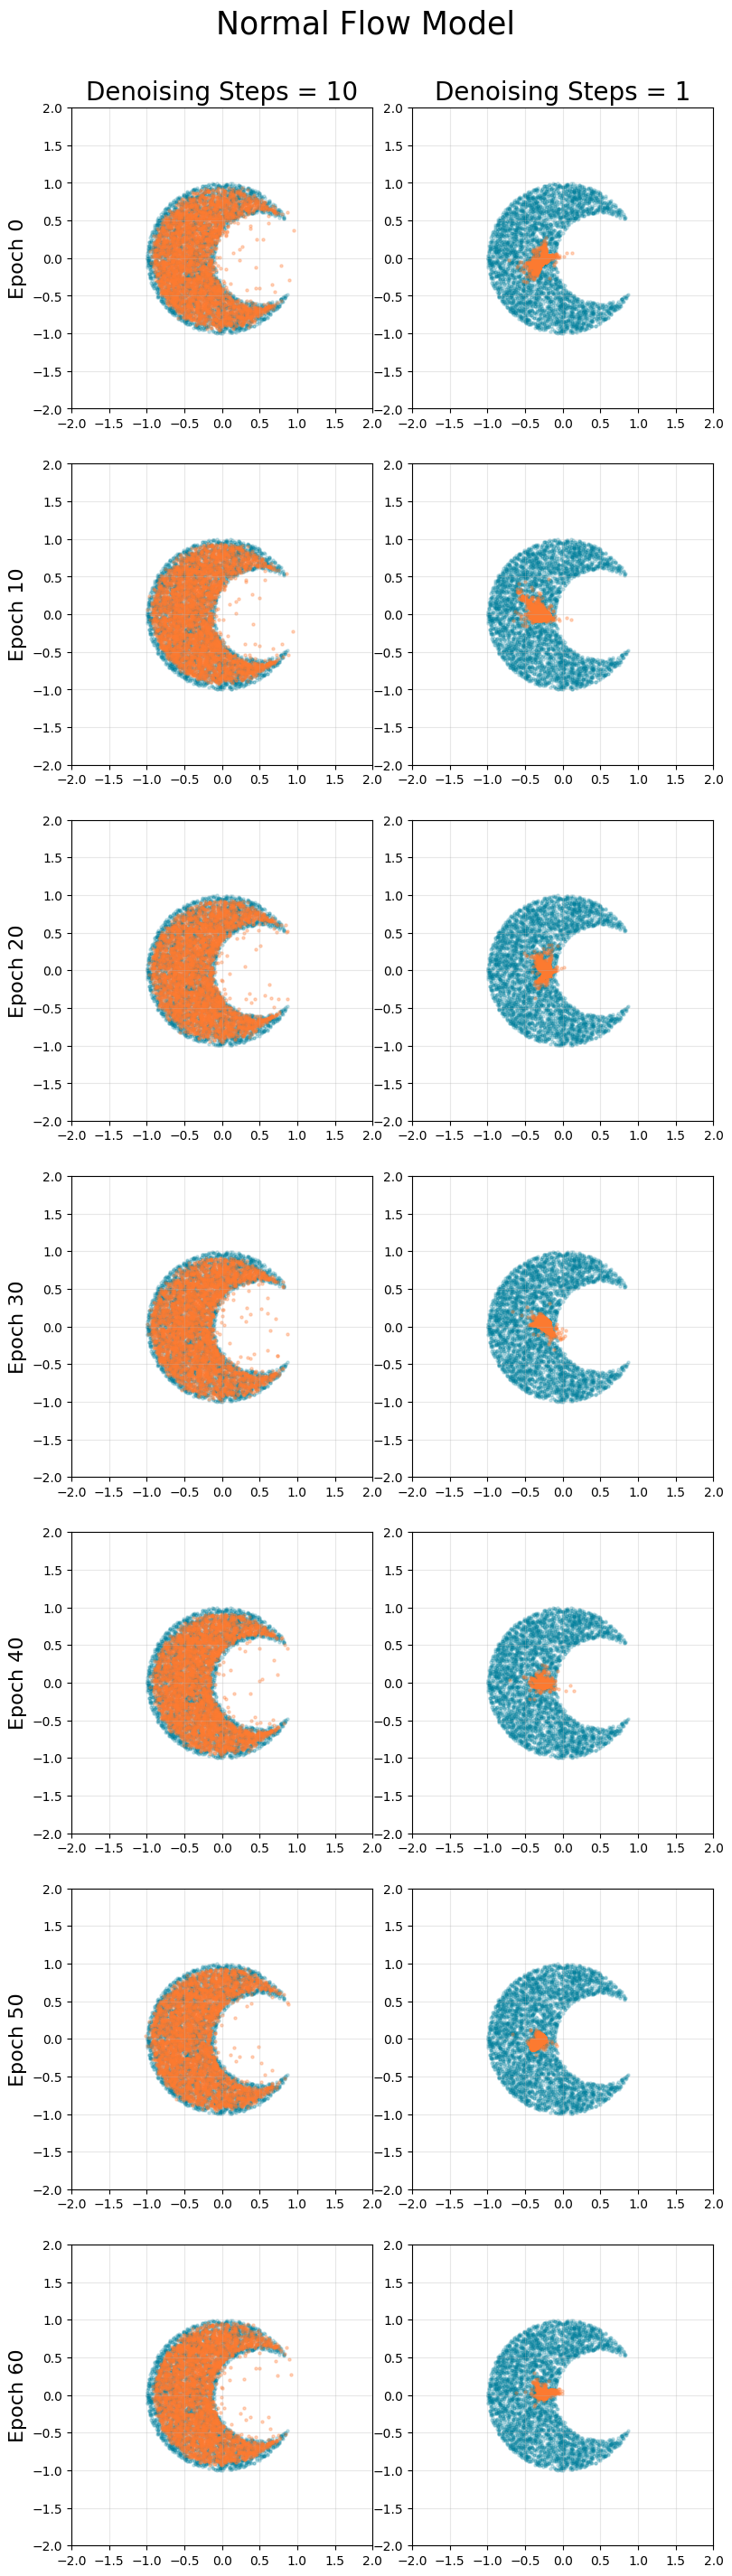

In [ ]:
# @title Visualization
visualize_denoising_progress(
    n_epochs=n_epoch_flow,
    initial_points=initial_points,
    num_steps_multi=10,
    model_class=VelocityNet,
    model_kwargs={'input_dim': 2, 'h_dim': 128},  # model initialization parameters
    target_points=target_points,
    integration_fn = forward_euler_integration_model,
    checkpoint_prefix=crescent_checkpoint_prefix,
    suptitle="Normal Flow Model",
    epoch_step=30,
    device=device
)

## Mean Flow model

### Train code

In [37]:
# @title Mean Flow Model
model = MeanFlowNet(input_dim=2, h_dim=128).to(device)
mean_crescent_checkpoint_prefix='crescent_mean_flow_model'

In [38]:
# @title Mean Flow Training
n_epochs = 100

start_time = time.time()

trained_model = train_mean_model(
    model=model,
    source_data_function=source_generator.generate,
    target_data_function=target_generator_crescent.generate,
    n_epochs=n_epochs,
    lr=0.003,
    batch_size=4096,
    batches_per_epoch=50,
    epoch_save_freq=10,
    checkpoint_prefix=mean_crescent_checkpoint_prefix
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training took {elapsed_time:.2f} seconds")

Epoch [0/100], Avg Loss: 0.5193
Saved model checkpoint to crescent_mean_flow_model_epoch_0.pt
Epoch [1/100], Avg Loss: 0.4185
Epoch [2/100], Avg Loss: 0.4083
Epoch [3/100], Avg Loss: 0.4096
Epoch [4/100], Avg Loss: 0.4288
Epoch [5/100], Avg Loss: 0.4444
Epoch [6/100], Avg Loss: 0.4524
Epoch [7/100], Avg Loss: 0.4594
Epoch [8/100], Avg Loss: 0.4603
Epoch [9/100], Avg Loss: 0.4687
Epoch [10/100], Avg Loss: 0.4725
Saved model checkpoint to crescent_mean_flow_model_epoch_10.pt
Epoch [11/100], Avg Loss: 0.4748
Epoch [12/100], Avg Loss: 0.4699
Epoch [13/100], Avg Loss: 0.4742
Epoch [14/100], Avg Loss: 0.4711
Epoch [15/100], Avg Loss: 0.4773
Epoch [16/100], Avg Loss: 0.4799
Epoch [17/100], Avg Loss: 0.4818
Epoch [18/100], Avg Loss: 0.4795
Epoch [19/100], Avg Loss: 0.4851
Epoch [20/100], Avg Loss: 0.4944
Saved model checkpoint to crescent_mean_flow_model_epoch_20.pt
Epoch [21/100], Avg Loss: 0.4877
Epoch [22/100], Avg Loss: 0.4878
Epoch [23/100], Avg Loss: 0.4941
Epoch [24/100], Avg Loss: 0.49

### Visualization

Loading model crescent_mean_flow_model_epoch_0.pt
Loading model crescent_mean_flow_model_epoch_20.pt
Loading model crescent_mean_flow_model_epoch_40.pt
Loading model crescent_mean_flow_model_epoch_60.pt
Loading model crescent_mean_flow_model_epoch_80.pt
Loading model crescent_mean_flow_model_epoch_100.pt


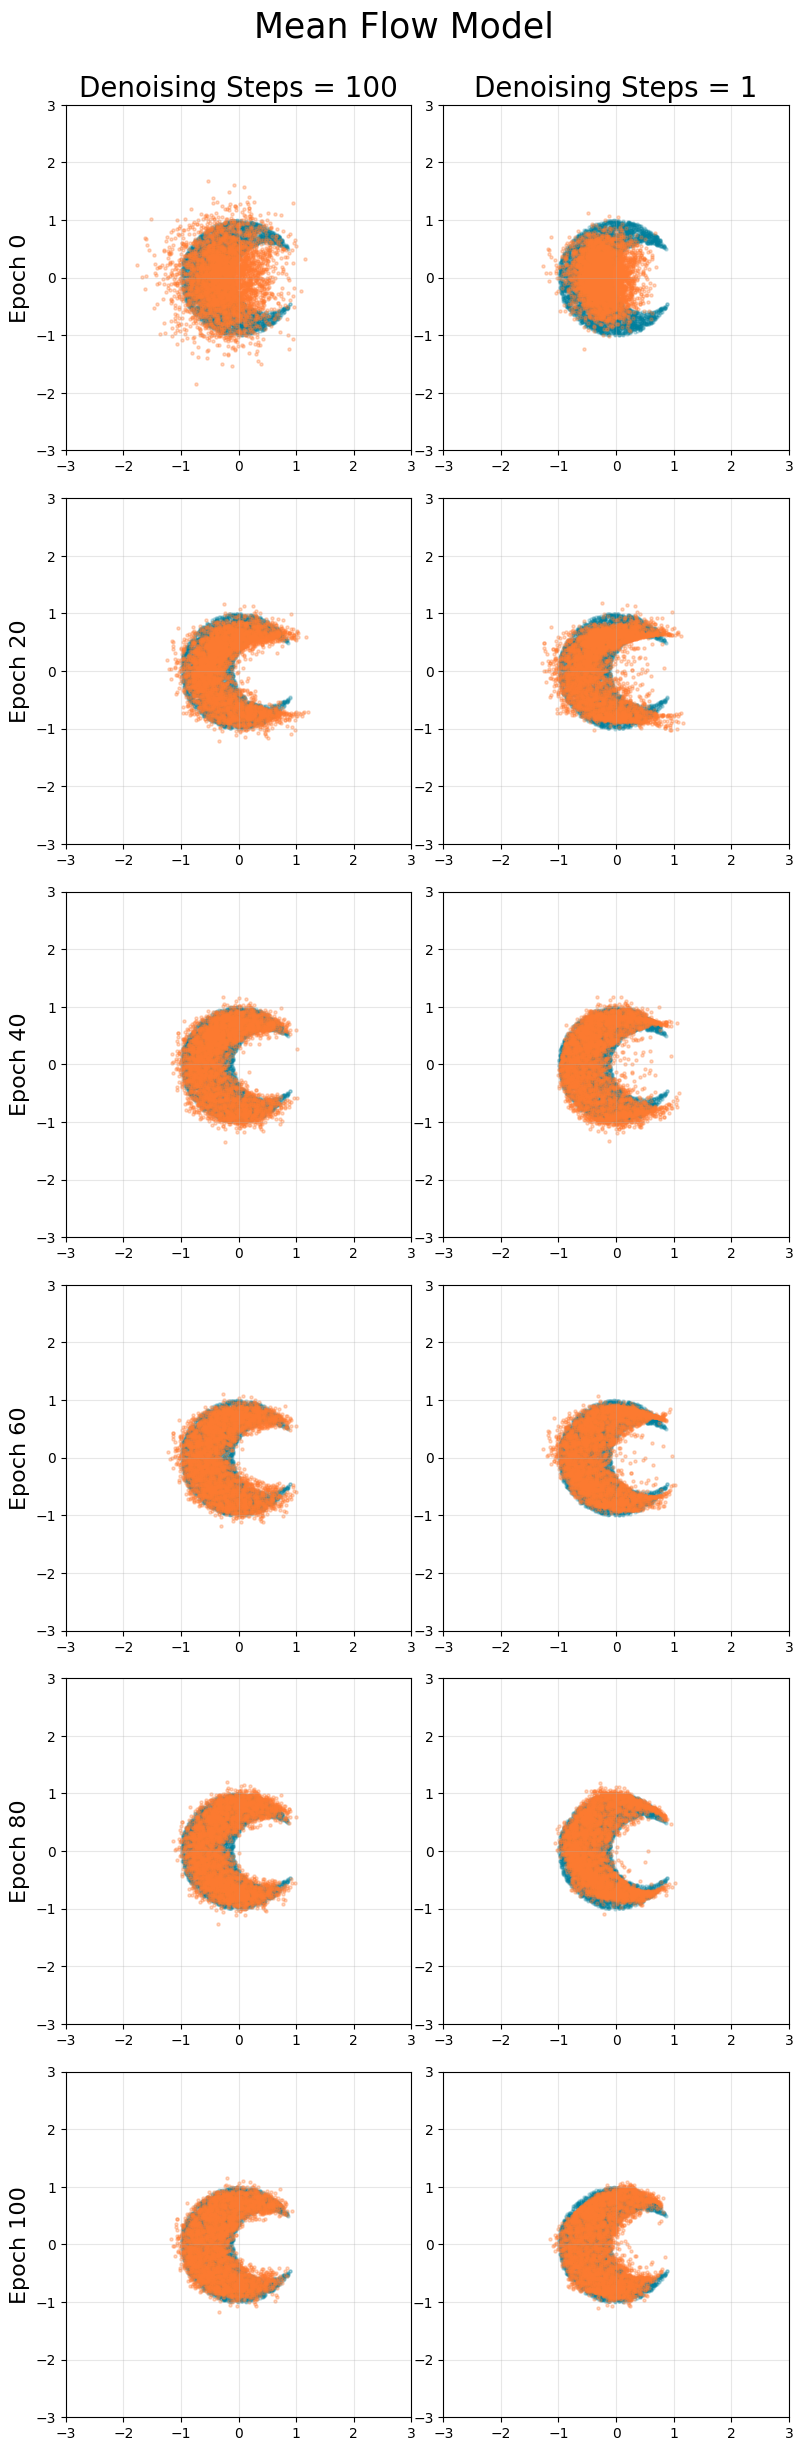

In [39]:
# @title Mean Flow Visualization
visualize_denoising_progress(
    n_epochs=n_epochs,
    initial_points=initial_points,
    num_steps_multi=100,
    model_class=MeanFlowNet,
    model_kwargs={'input_dim': 2, 'h_dim': 128},  # model initialization parameters
    target_points=target_points,
    integration_fn = forward_euler_integration_mean_model,
    checkpoint_prefix=mean_crescent_checkpoint_prefix,
    suptitle="Mean Flow Model",
    epoch_step=20,
    device=device
)

# Spiral Distribution

In [62]:
# @title Initialize Spiral
target_generator_spiral = SpiralGenerator(noise_std=0.05, n_turns=3, radius_scale=2)

# Generate test data
num_points = 4000
initial_points = source_generator.generate(num_points)
target_points = target_generator_spiral.generate(num_points)

## Flow Matching

In [64]:
# @title Flow Matching Model
model = VelocityNet(input_dim=2, h_dim=128).to(device)
spiral_checkpoint_prefix='spiral_flow_model'

### Training

In [42]:
# @title Training
n_epoch_flow = 80

start_time = time.time()

trained_model = train_model(
    model=model,
    source_data_function=source_generator.generate,
    target_data_function=target_generator_spiral.generate,
    n_epochs=n_epoch_flow,
    lr=0.003,
    batch_size=4096,
    batches_per_epoch=50,
    epoch_save_freq=10,
    checkpoint_prefix=spiral_checkpoint_prefix
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training took {elapsed_time:.2f} seconds")

Epoch [1/80], Avg Loss: 0.0227
Saved model checkpoint to spiral_flow_model_epoch_0.pt
Epoch [2/80], Avg Loss: 0.0226
Epoch [3/80], Avg Loss: 0.0219
Epoch [4/80], Avg Loss: 0.0222
Epoch [5/80], Avg Loss: 0.0225
Epoch [6/80], Avg Loss: 0.0224
Epoch [7/80], Avg Loss: 0.0222
Epoch [8/80], Avg Loss: 0.0220
Epoch [9/80], Avg Loss: 0.0218
Epoch [10/80], Avg Loss: 0.0221
Epoch [11/80], Avg Loss: 0.0218
Saved model checkpoint to spiral_flow_model_epoch_10.pt
Epoch [12/80], Avg Loss: 0.0218
Epoch [13/80], Avg Loss: 0.0221
Epoch [14/80], Avg Loss: 0.0219
Epoch [15/80], Avg Loss: 0.0223
Epoch [16/80], Avg Loss: 0.0218
Epoch [17/80], Avg Loss: 0.0224
Epoch [18/80], Avg Loss: 0.0215
Epoch [19/80], Avg Loss: 0.0216
Epoch [20/80], Avg Loss: 0.0216
Epoch [21/80], Avg Loss: 0.0221
Saved model checkpoint to spiral_flow_model_epoch_20.pt
Epoch [22/80], Avg Loss: 0.0216
Epoch [23/80], Avg Loss: 0.0229
Epoch [24/80], Avg Loss: 0.0220
Epoch [25/80], Avg Loss: 0.0222
Epoch [26/80], Avg Loss: 0.0218
Epoch [27/

### Visualization

Loading model spiral_flow_model_epoch_0.pt
Loading model spiral_flow_model_epoch_40.pt


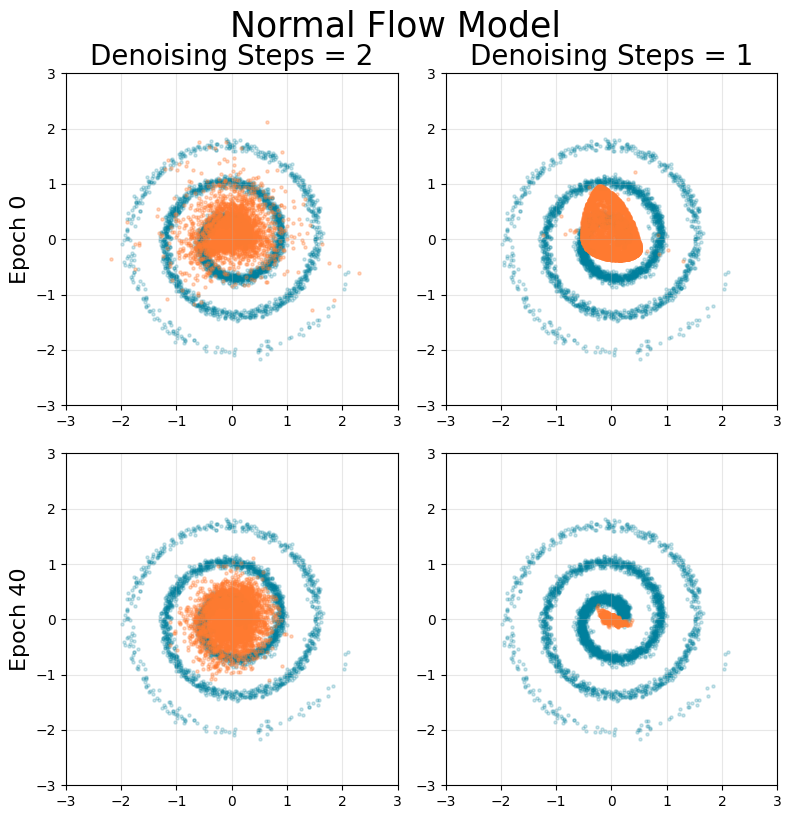

In [65]:
# @title Visualization
visualize_denoising_progress(
    n_epochs=n_epoch_flow,
    initial_points=initial_points,
    num_steps_multi=2,
    model_class=VelocityNet,
    model_kwargs={'input_dim': 2, 'h_dim': 128},  # model initialization parameters
    target_points=target_points,
    integration_fn = forward_euler_integration_model,
    checkpoint_prefix=spiral_checkpoint_prefix,
    suptitle="Normal Flow Model",
    epoch_step=40,
    device=device
)

## Mean Flow

### Training 

In [44]:
# @title Mean Flow Model
model = MeanFlowNet(input_dim=2, h_dim=128).to(device)
mean_spiral_checkpoint_prefix='spiral_mean_flow_model'

In [45]:
# @title Mean Flow Training
n_epochs = 100

start_time = time.time()

trained_model = train_mean_model(
    model=model,
    source_data_function=source_generator.generate,
    target_data_function=target_generator_spiral.generate,
    n_epochs=n_epochs,
    lr=0.003,
    batch_size=4096,
    batches_per_epoch=50,
    epoch_save_freq=10,
    checkpoint_prefix=mean_spiral_checkpoint_prefix
)

end_time = time.time()
elapsed_time = end_time - start_time
print(f"Training took {elapsed_time:.2f} seconds")

Epoch [0/100], Avg Loss: 0.8159
Saved model checkpoint to spiral_mean_flow_model_epoch_0.pt
Epoch [1/100], Avg Loss: 0.7841
Epoch [2/100], Avg Loss: 0.8299
Epoch [3/100], Avg Loss: 0.8222
Epoch [4/100], Avg Loss: 0.8220
Epoch [5/100], Avg Loss: 0.8188
Epoch [6/100], Avg Loss: 0.8207
Epoch [7/100], Avg Loss: 0.8241
Epoch [8/100], Avg Loss: 0.8261
Epoch [9/100], Avg Loss: 0.8183
Epoch [10/100], Avg Loss: 0.8226
Saved model checkpoint to spiral_mean_flow_model_epoch_10.pt
Epoch [11/100], Avg Loss: 0.8261
Epoch [12/100], Avg Loss: 0.8229
Epoch [13/100], Avg Loss: 0.8247
Epoch [14/100], Avg Loss: 0.8249
Epoch [15/100], Avg Loss: 0.8235
Epoch [16/100], Avg Loss: 0.8285
Epoch [17/100], Avg Loss: 0.8273
Epoch [18/100], Avg Loss: 0.8282
Epoch [19/100], Avg Loss: 0.8278
Epoch [20/100], Avg Loss: 0.8252
Saved model checkpoint to spiral_mean_flow_model_epoch_20.pt
Epoch [21/100], Avg Loss: 0.8301
Epoch [22/100], Avg Loss: 0.8271
Epoch [23/100], Avg Loss: 0.8331
Epoch [24/100], Avg Loss: 0.8260
Epo

### Visualization

Loading model spiral_mean_flow_model_epoch_0.pt
Loading model spiral_mean_flow_model_epoch_20.pt
Loading model spiral_mean_flow_model_epoch_40.pt
Loading model spiral_mean_flow_model_epoch_60.pt
Loading model spiral_mean_flow_model_epoch_80.pt
Loading model spiral_mean_flow_model_epoch_100.pt


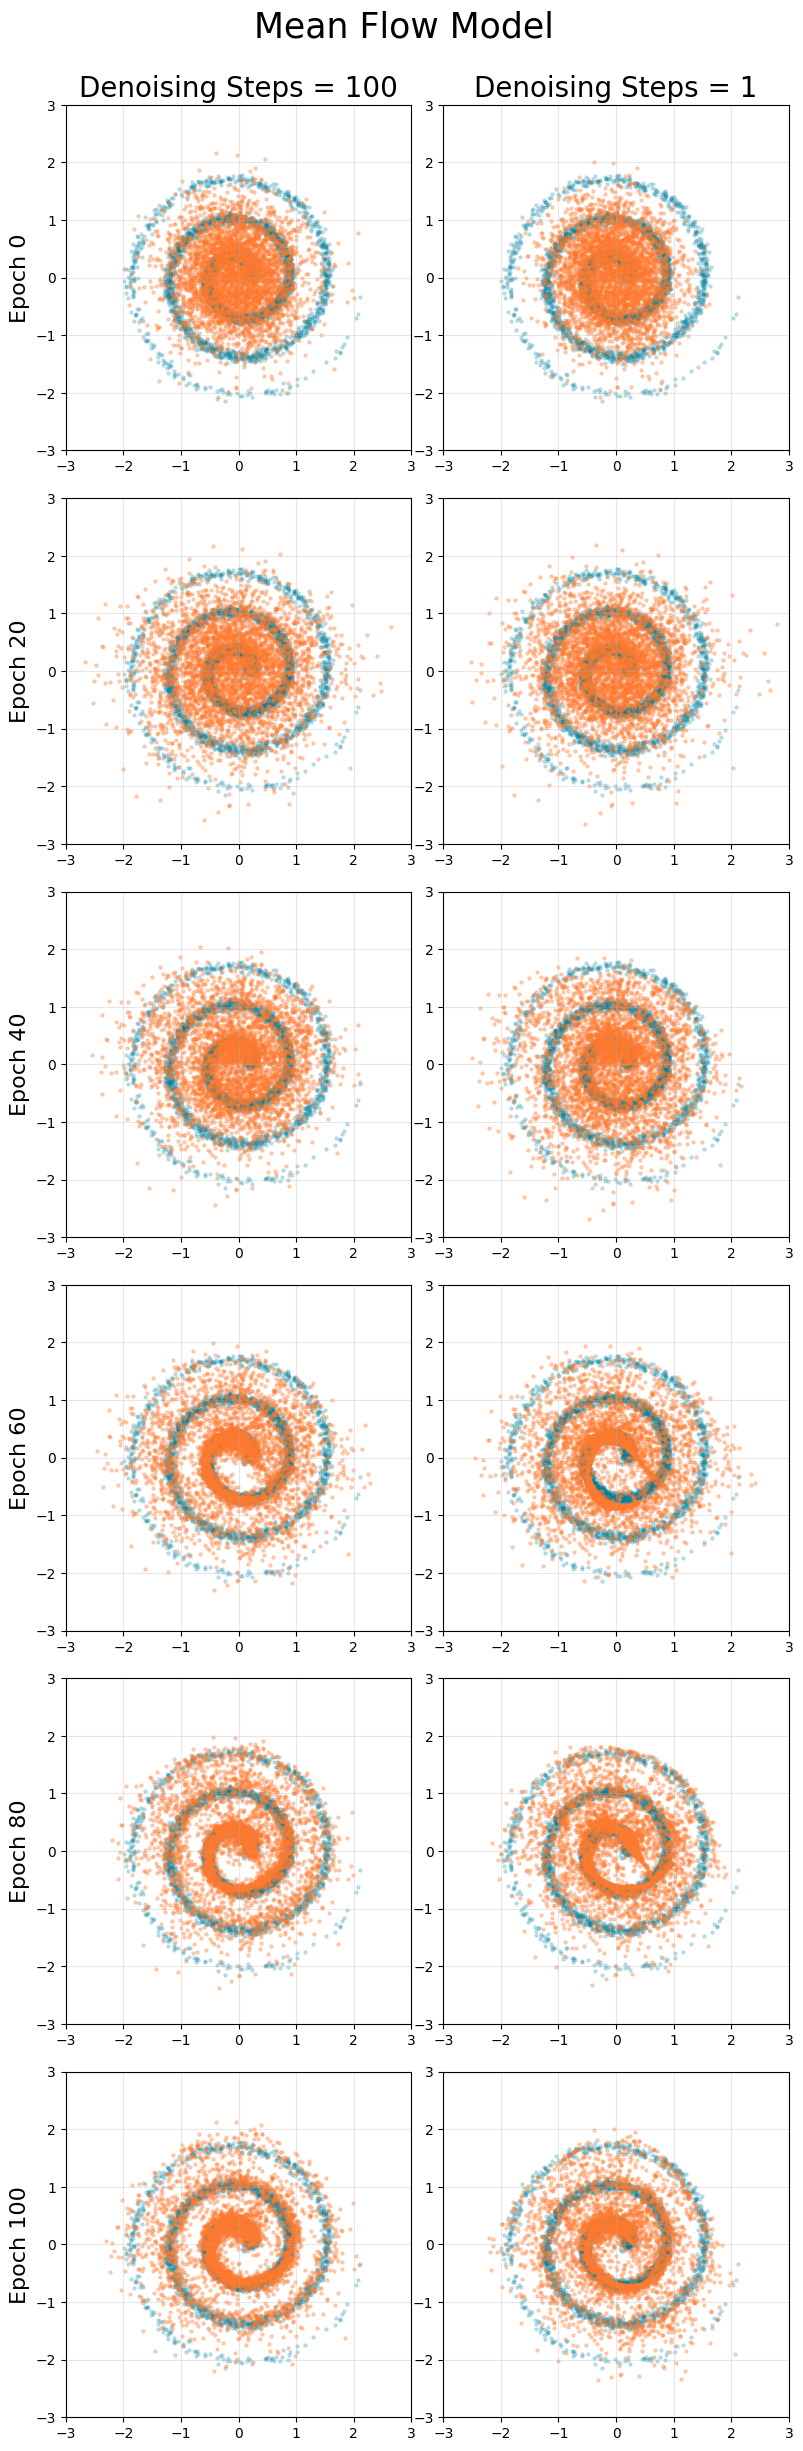

In [46]:
# @title Mean Flow Visualization
visualize_denoising_progress(
    n_epochs=n_epochs,
    initial_points=initial_points,
    num_steps_multi=100,
    model_class=MeanFlowNet,
    model_kwargs={'input_dim': 2, 'h_dim': 128},  # model initialization parameters
    target_points=target_points,
    integration_fn = forward_euler_integration_mean_model,
    checkpoint_prefix=mean_spiral_checkpoint_prefix,
    suptitle="Mean Flow Model",
    epoch_step=20,
    device=device
)